In [30]:
# Cell 1 – Import Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

In [41]:
# Cell 2 – Load & Explore Dataset
# Dataset appears to be the UCI Student Performance (Portuguese) dataset variant.
# Target we will model: G3 (final grade).

df = pd.read_csv("student-por 2.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("\nColumn names:", df.columns.tolist())

# Quick preview
display(df.head())

# Target stats
print(df["G3"].describe())

Shape: (649, 33)
Missing values: 0

Column names: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


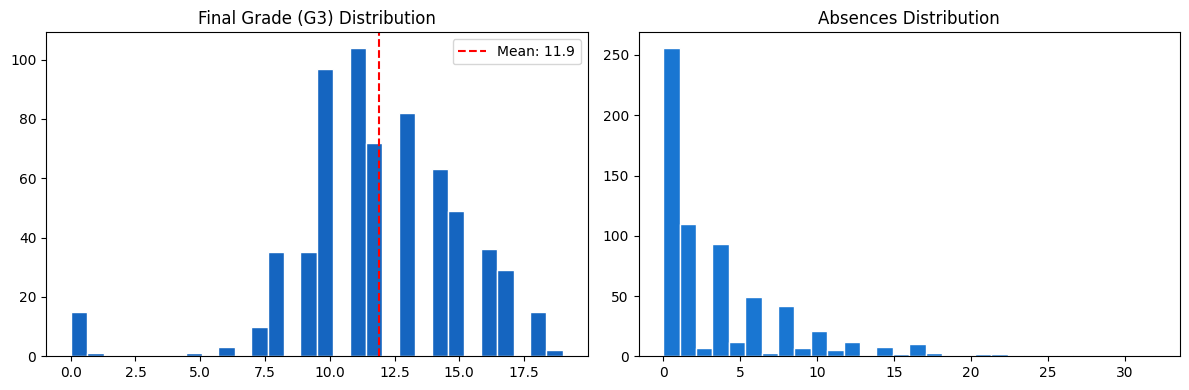

In [42]:
# Cell 3 – Distribution Plots (updated for G3 target)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["G3"], bins=30, color="#1565C0", edgecolor="white")
axes[0].axvline(
    df["G3"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['G3'].mean():.1f}",
)
axes[0].set_title("Final Grade (G3) Distribution")
axes[0].legend()

# Use absences as a second continuous variable to visualize
axes[1].hist(df["absences"], bins=30, color="#1976D2", edgecolor="white")
axes[1].set_title("Absences Distribution")

plt.tight_layout()
plt.show()

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/seaborn/regression.py:255: RuntimeWarning: divide by zero encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/seaborn/regression.py:255: RuntimeWarning: overflow encountered in dot
  yhat_boots = grid.dot(beta_boots).T
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/seaborn/regression.py:255: RuntimeWarning: invalid value encountered in dot
  yhat_boots = grid.dot(beta_boots).T


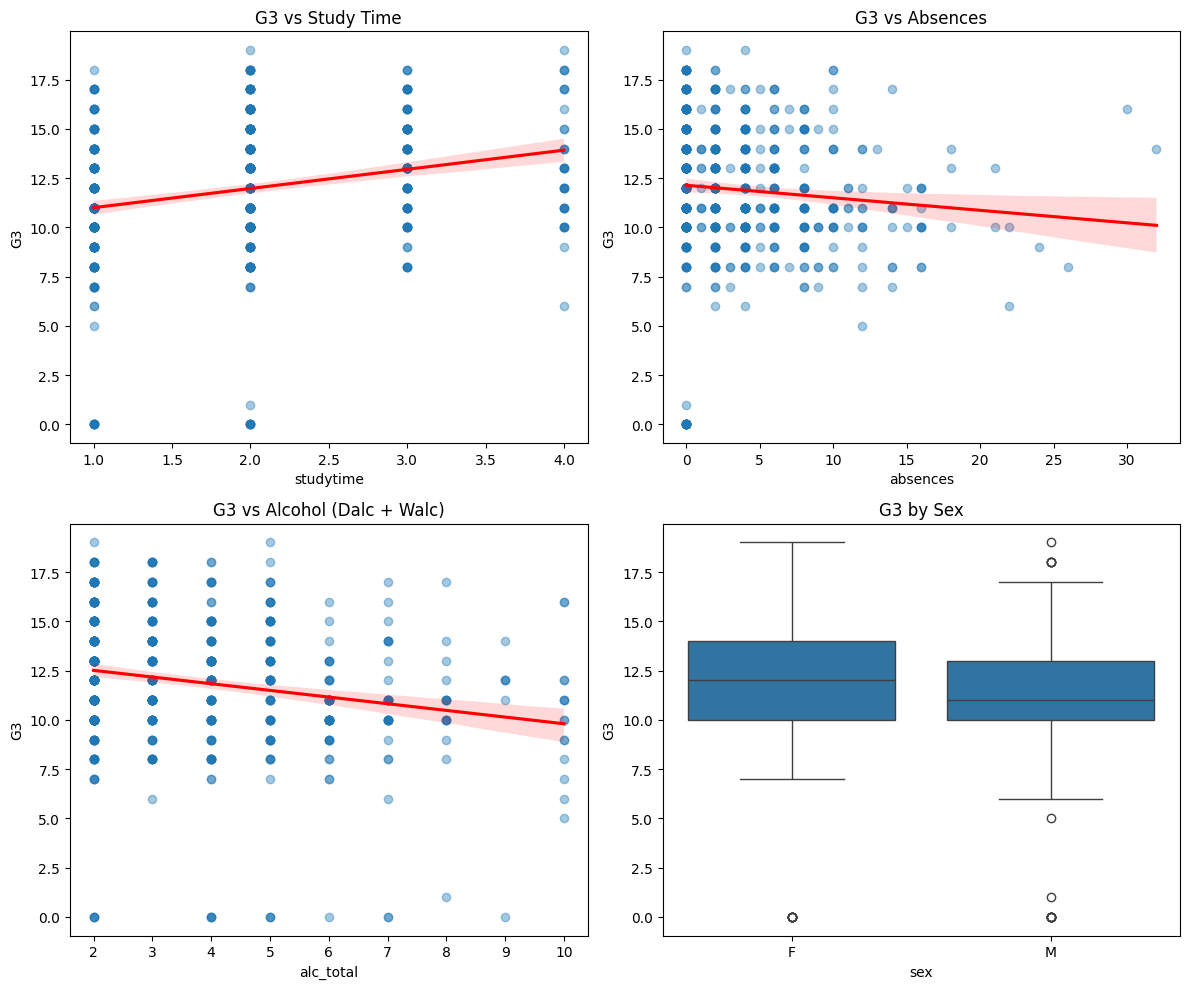

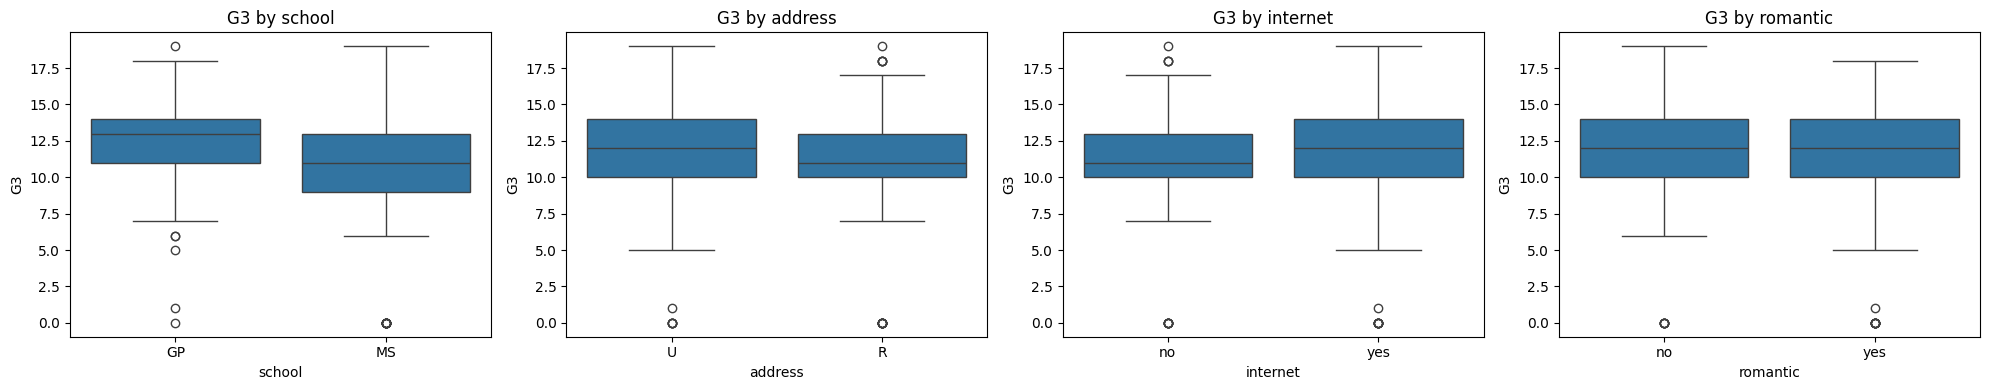

In [43]:
# Cell 3b – Extra Visualizations (scatter + categorical effects)
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure engineered feature exists for plotting (safe if rerun)
if "alc_total" not in df.columns and {"Dalc", "Walc"}.issubset(df.columns):
    df["alc_total"] = df["Dalc"] + df["Walc"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter: G3 vs studytime
sns.regplot(
    data=df,
    x="studytime",
    y="G3",
    ax=axes[0, 0],
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)
axes[0, 0].set_title("G3 vs Study Time")

# Scatter: G3 vs absences
sns.regplot(
    data=df,
    x="absences",
    y="G3",
    ax=axes[0, 1],
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
)
axes[0, 1].set_title("G3 vs Absences")

# Scatter: G3 vs alcohol total (if present)
if "alc_total" in df.columns:
    sns.regplot(
        data=df,
        x="alc_total",
        y="G3",
        ax=axes[1, 0],
        scatter_kws={"alpha": 0.4},
        line_kws={"color": "red"},
    )
    axes[1, 0].set_title("G3 vs Alcohol (Dalc + Walc)")
else:
    axes[1, 0].axis("off")

# Boxplot: G3 by sex (categorical)
if "sex" in df.columns:
    sns.boxplot(data=df, x="sex", y="G3", ax=axes[1, 1])
    axes[1, 1].set_title("G3 by Sex")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Additional categorical comparisons (optional)
cat_cols = [c for c in ["school", "address", "internet", "romantic"] if c in df.columns]
if len(cat_cols) > 0:
    n = len(cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        sns.boxplot(data=df, x=col, y="G3", ax=ax)
        ax.set_title(f"G3 by {col}")
    plt.tight_layout()
    plt.show()


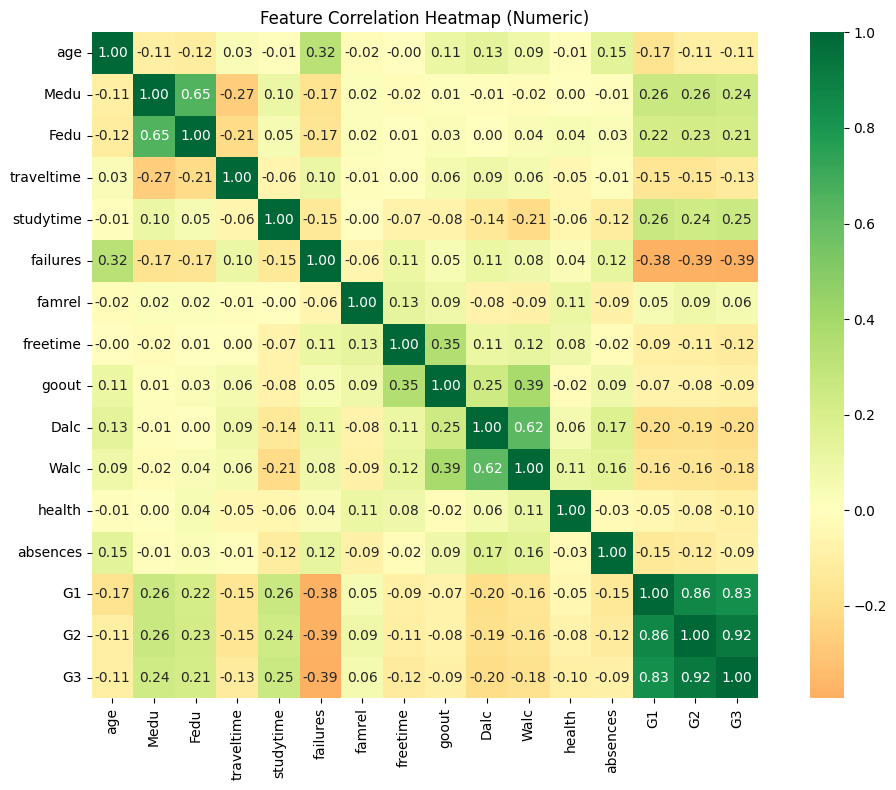

In [44]:
# Cell 4 – Correlation Heatmap (numeric columns)
# For this dataset, numeric columns include grades (G1,G2,G3) and other integer scales.
num_cols = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3",
]

corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True)
plt.title("Feature Correlation Heatmap (Numeric)")
plt.tight_layout()
plt.show()



In [45]:
# Cell 5 – Feature Engineering
# Target: 1 = High Performer (G3 >= threshold), 0 = Struggling
# Common convention: pass if >=10 (out of 20)
threshold = 10

# Example engineered feature: alcohol total
# (Not necessary, but useful and safe)
df["alc_total"] = df["Dalc"] + df["Walc"]

df["performance_class"] = (df["G3"] >= threshold).astype(int)
print(df["performance_class"].value_counts())

performance_class
1    549
0    100
Name: count, dtype: int64


In [46]:
# Cell 6 – Encode & Scale
# Drop target and (optionally) intermediate grades to avoid trivial leakage.
# If you want a more realistic early-season model, drop G1 and G2.
drop_grade_leaks = True

drop_cols = ["G3", "performance_class"]
if drop_grade_leaks:
    drop_cols += ["G1", "G2"]

X = df.drop(columns=drop_cols)
y = df["performance_class"]

# One-hot encode categoricals (more appropriate than LabelEncoder for >2 classes)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " | Test:", X_test_scaled.shape)

Train: (519, 40)  | Test: (130, 40)


In [47]:
# Cell 7 – Train All 3 Models
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

dt = DecisionTreeClassifier(random_state=42, max_depth=8)
dt.fit(X_train, y_train)  # trees do not require scaling
dt_pred = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)  # trees do not require scaling
rf_pred = rf.predict(X_test)

print("All 3 models trained successfully!")

All 3 models trained successfully!


/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/s

Logistic Regression       79.23%
Decision Tree             76.15%
Random Forest             79.23%


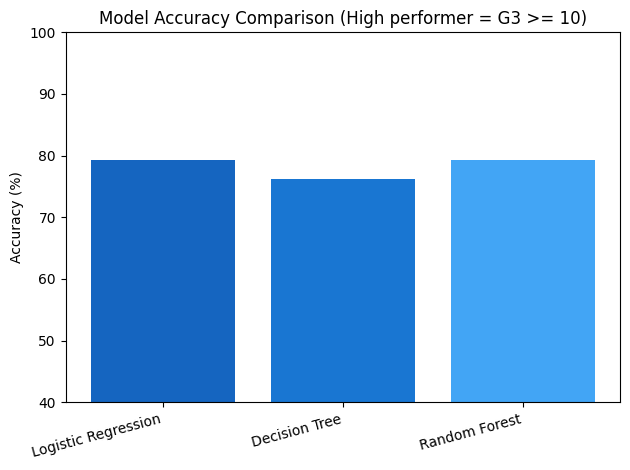

In [48]:
# Cell 8 – Compare Accuracies
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accs = [
    accuracy_score(y_test, lr_pred) * 100,
    accuracy_score(y_test, dt_pred) * 100,
    accuracy_score(y_test, rf_pred) * 100,
]

for m, a in zip(models, accs):
    print(f"{m:<25} {a:.2f}%")

plt.bar(models, accs, color=["#1565C0", "#1976D2", "#42A5F5"])
plt.title(f"Model Accuracy Comparison (High performer = G3 >= {threshold})")
plt.ylabel("Accuracy (%)")
plt.ylim(40, 100)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

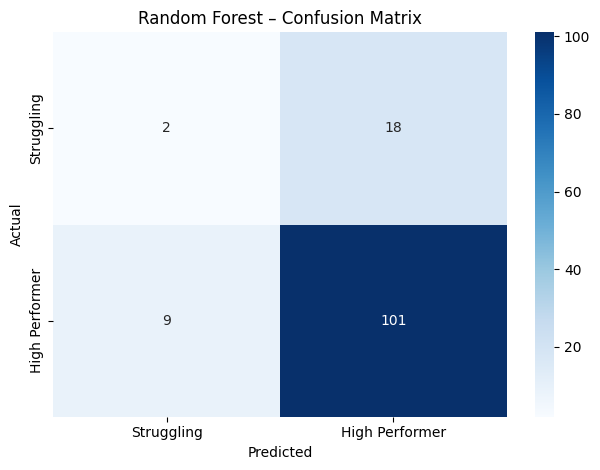

                precision    recall  f1-score   support

    Struggling       0.18      0.10      0.13        20
High Performer       0.85      0.92      0.88       110

      accuracy                           0.79       130
     macro avg       0.52      0.51      0.51       130
  weighted avg       0.75      0.79      0.77       130



In [49]:
# Cell 9 – Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Struggling", "High Performer"],
    yticklabels=["Struggling", "High Performer"],
)
plt.title("Random Forest – Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Struggling", "High Performer"],
    )
)




/var/folders/ql/hdbyk3lx6vq0x6fs9227fc_m0000gn/T/ipykernel_55095/680886614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Blues_r")


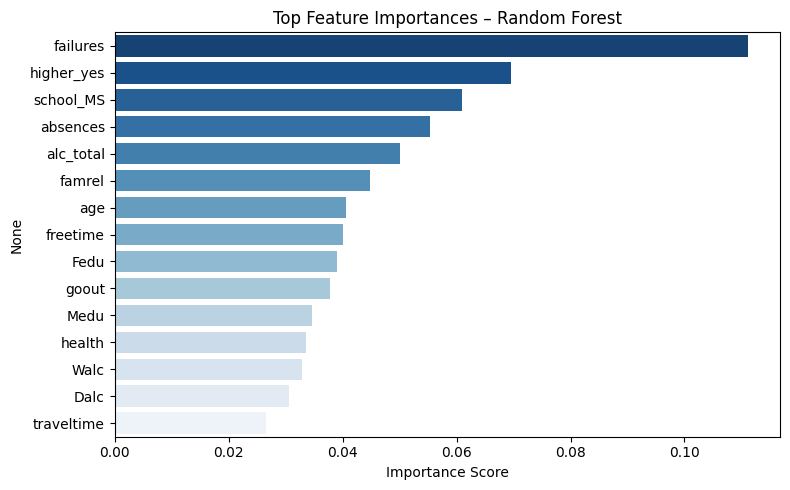

In [50]:
# Cell 10 – Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Blues_r")
plt.title("Top Feature Importances – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()